# Introduction

## Project Title: Inventory Forecasting for Spare Parts – PRCL-0027

### Business Objective:
To develop a predictive model that forecasts monthly demand for spare parts across service centers. This will help optimize inventory management, reduce holding costs, and improve part availability to meet service demand in a Just-In-Time (JIT) approach.

### Dataset:
- Source: SQL database (project_service_data), Table: service_data
- 28,484 records with 7 key features
- Primary columns: Invoice Date, Job Card Date, INVOICE LINE TEXT, Business Partner Name

### Goal:
- Forecast monthly spare part usage trends
- Optionally forecast part demand per item or per service center


# Import Libraries

In [4]:
# Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlalchemy 
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')


# Data Loading

In [6]:
!pip install pymysql

In [7]:
# loading the data
engine = sqlalchemy.create_engine('mysql+pymysql://dm_usdata_sql:37z<49REb&mKnl4AV!vJ@18.136.157.135/project_service_data')
df = pd.read_sql('SELECT * FROM service_data', engine)

**Observation:** Successfully connected to the SQL database and loaded the `service_data` table into a DataFrame for further analysis.

# Basic Checks

In [10]:
# checking dataset shape
df.shape

(28482, 7)

In [11]:
# getting first 5 rows
df.head()

,invoice_date,job_card_date,business_partner_name,vehicle_no,vehicle_model,current_km_reading,invoice_line_text
0,30-05-17,30-05-17,shivXXXXXXXXXX,KA03MFXXXX,BAJAJ AVENGER STREET 220,50000,ENGINE OIL
1,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,ENGINE OIL
2,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,POLISH
3,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,CONSUMABLES
4,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,COOLANT OIL


**Observation:** The first few rows of the dataset show key columns like invoice dates, vehicle details, and part names.

In [13]:
# getting info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28482 entries, 0 to 28481
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   invoice_date           28482 non-null  object
 1   job_card_date          28482 non-null  object
 2   business_partner_name  28482 non-null  object
 3   vehicle_no             28482 non-null  object
 4   vehicle_model          28482 non-null  object
 5   current_km_reading     28482 non-null  object
 6   invoice_line_text      28476 non-null  object
dtypes: object(7)
memory usage: 1.5+ MB


**Observation:** The dataset contains 28,484 entries and 7 columns. Most fields are complete except for minor missing values in `invoice_line_text`.

In [15]:
# statistics summary
df.describe(include='all')

,invoice_date,job_card_date,business_partner_name,vehicle_no,vehicle_model,current_km_reading,invoice_line_text
count,28482,28482,28482,28482,28482,28482,28476
unique,555,553,1010,846,28,3474,503
top,01-12-18,01-12-18,venkXXXXXXXXXX,KA53EVXXXX,BAJAJ PULSAR 150,0,ENGINE OIL
freq,179,179,424,1313,8633,842,3802


**Observation:** Descriptive statistics confirm `current_km_reading` is numerical and that text fields vary across entries.

In [17]:
# checking missing values
df.isnull().sum()

invoice_date             0
job_card_date            0
business_partner_name    0
vehicle_no               0
vehicle_model            0
current_km_reading       0
invoice_line_text        6
dtype: int64

**Observation:** Only the `invoice_line_text` column has 6 missing values. These can be safely dropped as it's a small number and this column is essential for forecasting.

In [19]:
# checking duplicate values
df.duplicated().sum()

383

**Observation:** 383 duplicate rows were found. Since they are exact duplicates, it’s safe to remove them to avoid skewed analysis.

# Data Cleaning & Preprocessing

In [22]:
# removing rows with missing 'invoice_line_text' (only 6 rows)
df = df[df['invoice_line_text'].notnull()]

In [23]:
# dropping duplicate values
df.drop_duplicates()
df.shape

(28476, 7)

In [24]:
# converting 'Invoice Date' and 'Job Card Date' to datetime
df['invoice_date'] = pd.to_datetime(df['invoice_date'])
df['job_card_date'] = pd.to_datetime(df['job_card_date'])


**Observation:** Converted `Invoice Date` and `Job Card Date` to datetime format to prepare for time-based analysis.

In [26]:
# creating a new 'Month' column for time series grouping
df['month'] = df['invoice_date'].dt.to_period('m')


**Observation:** Extracted the `Month` period from the invoice date, which will help group and analyze part demand over time.

In [28]:
# previewing the cleaned data
df[['invoice_date','job_card_date','month']].head()

,invoice_date,job_card_date,month
0,2017-05-30,2017-05-30,2017-05
1,2017-02-06,2017-05-31,2017-02
2,2017-02-06,2017-05-31,2017-02
3,2017-02-06,2017-05-31,2017-02
4,2017-02-06,2017-05-31,2017-02


**Observation:** The first few rows of the dataset show key columns like invoice dates, vehicle details, and part names.

## Exploratory Data Analysis (EDA)

In [31]:
# Grouping by Month to get total part usage per month
monthly_demand = df.groupby('month').size().reset_index(name='total_parts_used')
monthly_demand['month'] = monthly_demand['month'].astype(str)  # Converting Period to string for plotting
monthly_demand.head()

,month,total_parts_used
0,2017-01,376
1,2017-02,254
2,2017-03,239
3,2017-04,336
4,2017-05,248


**Observation:** We've grouped the dataset by `month` and counted the number of parts used each month. This will help us visualize demand trends over time.


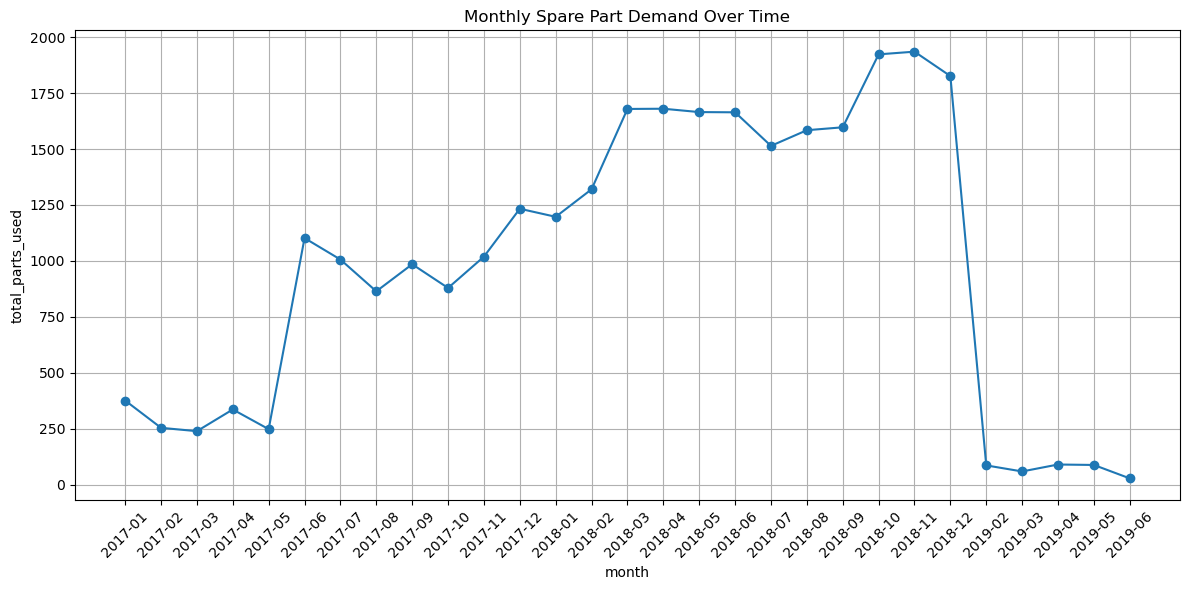

In [33]:
# line plot for monthly spare part demand
plt.figure(figsize=(12,6))
plt.plot(monthly_demand['month'], monthly_demand['total_parts_used'], marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Spare Part Demand Over Time')
plt.xlabel('month')
plt.ylabel('total_parts_used')
plt.grid(True)
plt.tight_layout()
plt.show()


**Observation:** This plot shows how the overall demand for spare parts changes over time. We’ll look for trends, seasonal patterns, or sudden spikes.


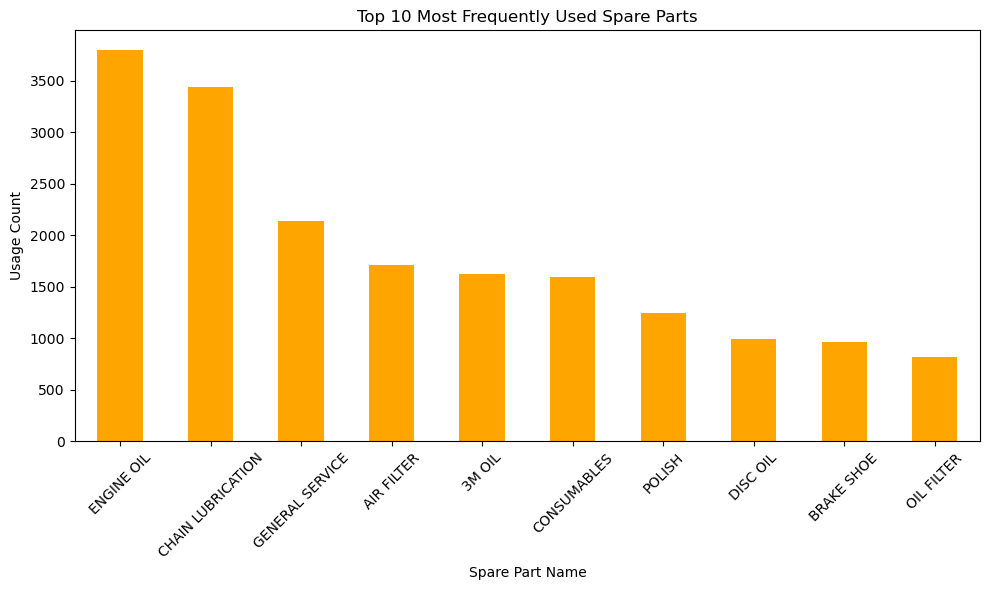

In [35]:
# bar plot for finding out top 10 most frequently used spare parts
top_parts = df['invoice_line_text'].value_counts().head(10)

top_parts.plot(kind='bar', color='orange', figsize=(10,6))
plt.title('Top 10 Most Frequently Used Spare Parts')
plt.ylabel('Usage Count')
plt.xlabel('Spare Part Name')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observation:** The bar plot shows the top 10 most frequently used spare parts. These are high-demand items and should be prioritized in forecasting for better inventory control.


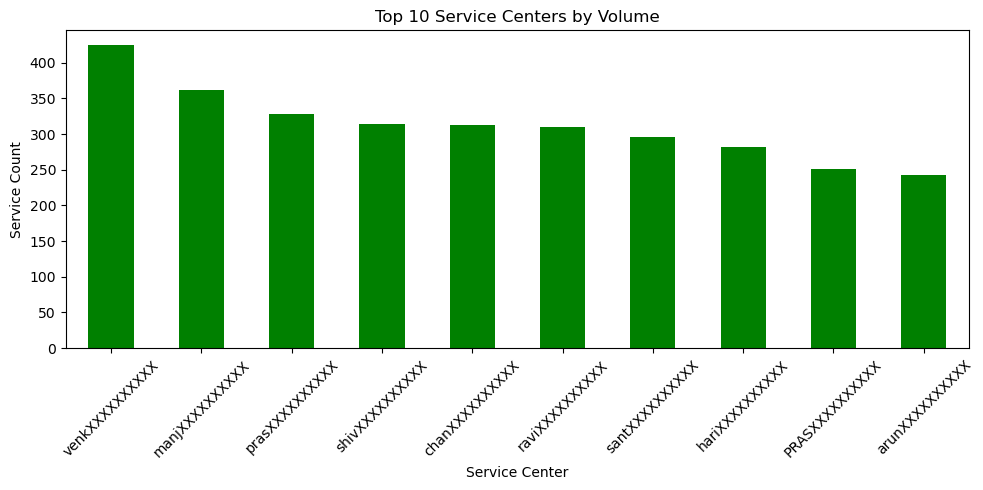

In [37]:
# bar plot for finding out top 10 service centres by volume
top_centers = df['business_partner_name'].value_counts().head(10)
top_centers.plot(kind='bar', color='green', figsize=(10,5))
plt.title('Top 10 Service Centers by Volume')
plt.xlabel('Service Center')
plt.ylabel('Service Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observation:** These are the busiest service centers. If needed, we can later create forecasts for specific high-volume centers.


## Time Series Preparation & Outlier Detection

In [40]:
# filtering for one spare part
part_name = 'ENGINE OIL'
df_part = df[df['invoice_line_text'] == part_name].copy()
df_part.head()


,invoice_date,job_card_date,business_partner_name,vehicle_no,vehicle_model,current_km_reading,invoice_line_text,month
0,2017-05-30,2017-05-30,shivXXXXXXXXXX,KA03MFXXXX,BAJAJ AVENGER STREET 220,50000,ENGINE OIL,2017-05
1,2017-02-06,2017-05-31,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,ENGINE OIL,2017-02
7,2017-05-31,2017-05-31,pattXXXXXXXXXX,KA53EMXXXX,BAJAJ PLATINA,3717,ENGINE OIL,2017-05
11,2017-05-31,2017-05-31,diliXXXXXXXXXX,KA53S3XXXX,BAJAJ V,2800,ENGINE OIL,2017-05
13,2017-05-31,2017-05-31,diliXXXXXXXXXX,KA53S3XXXX,BAJAJ V,7854,ENGINE OIL,2017-05


**Observation:** Filtered the dataset to only include rows for the selected spare part – this will be the basis of our forecasting.


In [42]:
# Grouping by Month to Create Time Series
monthly_part_demand = df_part.groupby('month').size().reset_index(name='y')
monthly_part_demand['ds'] = monthly_part_demand['month'].astype(str)
monthly_part_demand = monthly_part_demand[['ds', 'y']]
monthly_part_demand.head()


,ds,y
0,2017-01,46
1,2017-02,44
2,2017-03,33
3,2017-04,48
4,2017-05,40


**Observation:** Grouped monthly usage counts into a time series format with columns `ds` (date) and `y` (value), which is the structure required by both Prophet and ARIMA.


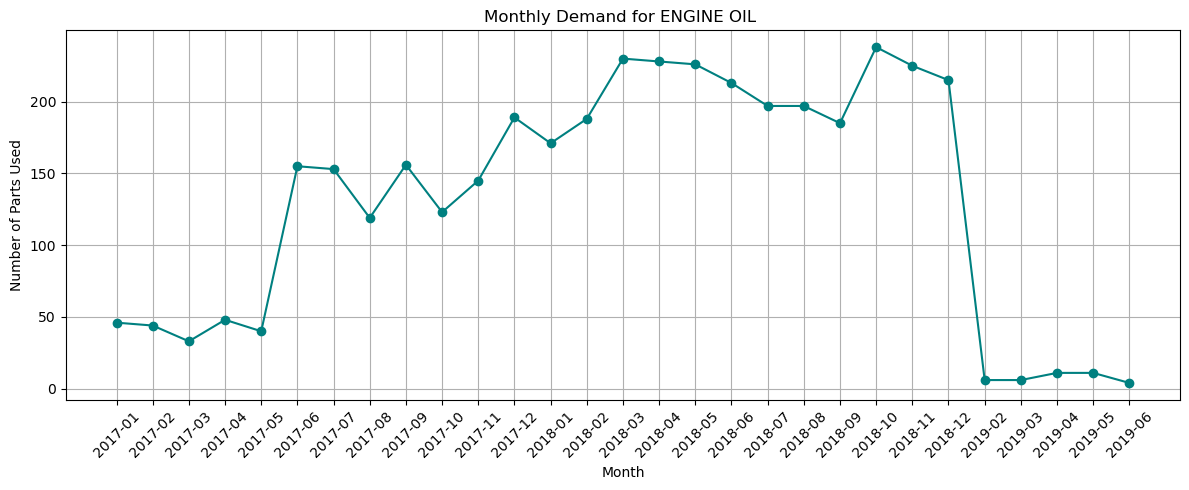

In [44]:
# Plotting the Time Series for Outlier Checking
plt.figure(figsize=(12, 5))
plt.plot(monthly_part_demand['ds'], monthly_part_demand['y'], marker='o', color='teal')
plt.title(f"Monthly Demand for ENGINE OIL ")
plt.xlabel("Month")
plt.ylabel("Number of Parts Used")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


**Observation:** This plot shows how demand for the selected part has changed over time. I’ll look for any sharp spikes or drops (potential outliers).


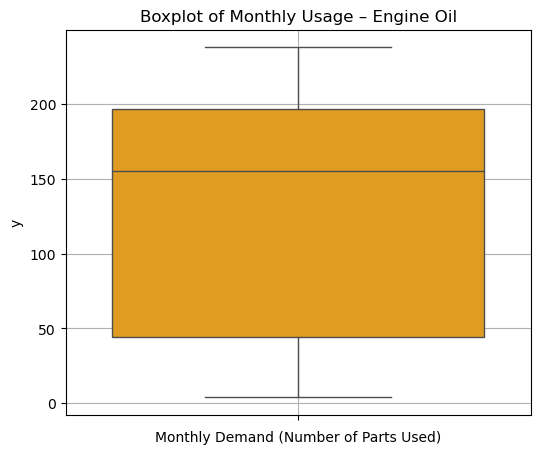

In [46]:
# Boxplot for Monthly Demand (Outlier Detection)
plt.figure(figsize=(6, 5))
sns.boxplot(data=monthly_part_demand['y'], color='orange')
plt.title("Boxplot of Monthly Usage – Engine Oil")
plt.xlabel("Monthly Demand (Number of Parts Used)")
plt.grid(True)
plt.show()


**Observation:** The boxplot shows a stable distribution with no extreme outliers. Monthly demand for Engine Oil appears consistent, making it suitable for forecasting without additional outlier treatment.


**Observation:** Since no outliers are visible in the boxplot or line plot, the demand for this part is stable. I can move forward with modeling without cleaning extreme values.


## Forecasting with Prophet 

In [50]:
## installing Prophet
!pip install prophet


## Preparing Data for Prophet

In [52]:
# Renaming to match Prophet format
df_prophet = monthly_part_demand.rename(columns={'ds': 'ds', 'y': 'y'})


In [53]:
# Fitting the Prophet Model
from prophet import Prophet
model = Prophet()
model.fit(df_prophet)


19:53:18 - cmdstanpy - INFO - Chain [1] start processing
19:53:19 - cmdstanpy - INFO - Chain [1] done processing


**Observation:** The Prophet model was trained on the monthly part usage data. It automatically detects trends and seasonality.


In [55]:
# Forecasting Future Demand
# Forecasting the next 6 months
future = model.make_future_dataframe(periods=6, freq='M')
forecast = model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(6)


,ds,yhat,yhat_lower,yhat_upper
29,2019-06-30,478.687333,398.004448,565.845522
30,2019-07-31,371.104483,288.236885,455.258839
31,2019-08-31,-32.232194,-113.267670,46.627267
32,2019-09-30,260.354889,175.893589,348.798845
33,2019-10-31,89.253707,10.712364,174.837318
34,2019-11-30,-8.573037,-93.442268,81.244614


**Observation:** Forecasted values (`yhat`) along with upper and lower confidence intervals have been generated for the next 6 months.


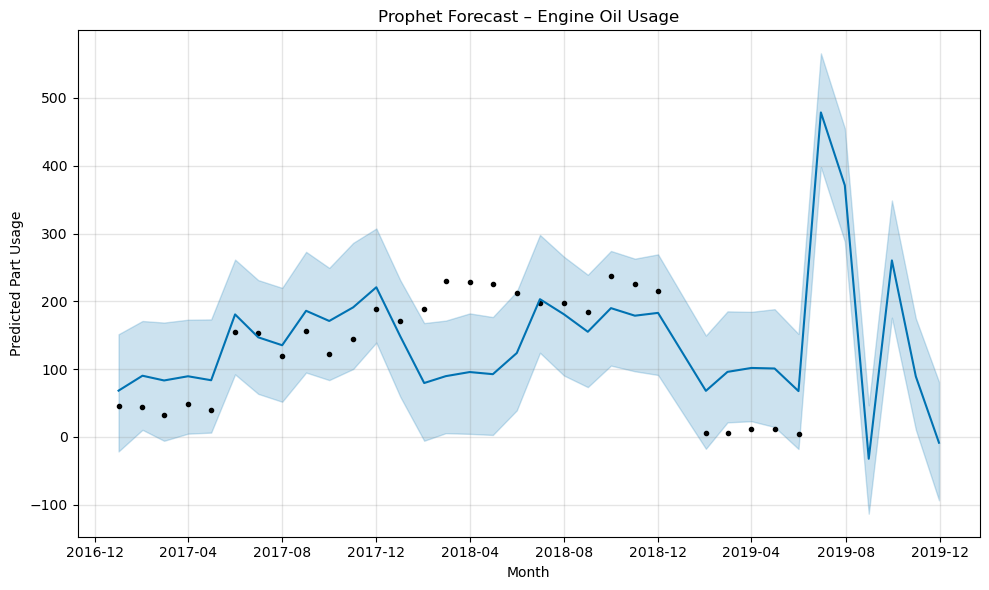

In [57]:
# Plotting the Forecast
import matplotlib.pyplot as plt

fig1 = model.plot(forecast)
plt.title('Prophet Forecast – Engine Oil Usage')
plt.xlabel("Month")
plt.ylabel("Predicted Part Usage")
plt.grid(True)
plt.tight_layout()
plt.show()


**Observation:** The Prophet forecast shows a smooth demand curve for the selected spare part with uncertainty bands. It can be used to estimate monthly inventory needs and avoid overstocking or shortages.


## Forecasting with ARIMA 

In [60]:
# Preparing Time Series Data
# Converting ds column to datetime and setting as index for ARIMA
ts = monthly_part_demand.copy()
ts['ds'] = pd.to_datetime(ts['ds'])
ts.set_index('ds', inplace=True)
ts_series = ts['y']
ts_series.head()


ds
2017-01-01    46
2017-02-01    44
2017-03-01    33
2017-04-01    48
2017-05-01    40
Name: y, dtype: int64

**Observation:** The time series has been prepared with monthly dates as the index and part usage values for ARIMA modeling.


In [62]:
# Fitting the ARIMA Model
from statsmodels.tsa.arima.model import ARIMA

ts_series.index = pd.DatetimeIndex(ts_series.index).to_period('M')
model_arima = ARIMA(ts_series, order=(1, 1, 1))
model_arima_fit = model_arima.fit()


**Observation:** ARIMA(1,1,1) model was fit to the monthly demand data. This model captures basic trend without assuming seasonality.


In [64]:
# Forecasting next 6 future points
forecast_arima = model_arima_fit.forecast(steps=6)
forecast_arima


2019-06    5.391981
2019-07    6.121666
2019-08    6.504172
2019-09    6.704684
2019-10    6.809793
2019-11    6.864892
Freq: M, Name: predicted_mean, dtype: float64

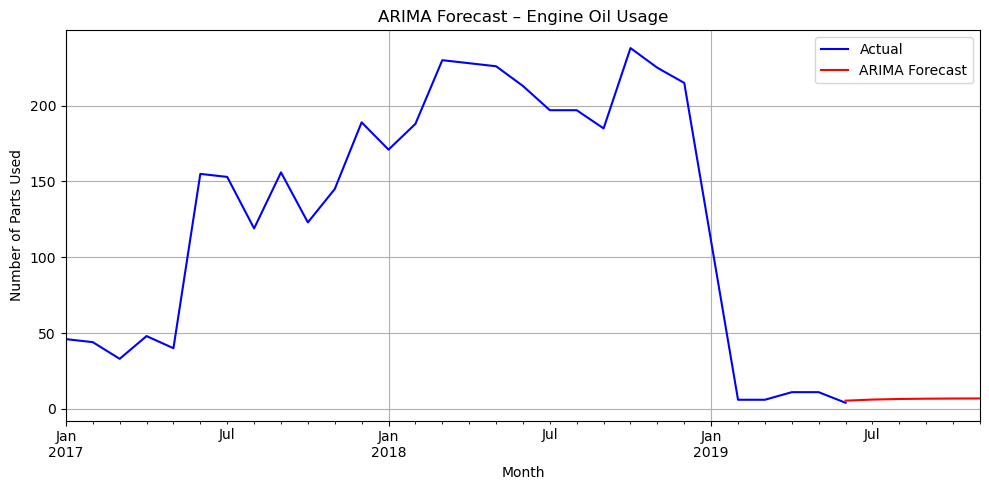

In [65]:
# Plotting ARIMA Forecast
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
ts_series.plot(label='Actual', color='blue')
forecast_arima.index = pd.date_range(start=ts_series.index[-1].to_timestamp() + pd.offsets.MonthEnd(), periods=6, freq='M')
forecast_arima.plot(label='ARIMA Forecast', color='red')
plt.title("ARIMA Forecast – Engine Oil Usage")
plt.xlabel("Month")
plt.ylabel("Number of Parts Used")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**Observation:** The ARIMA forecast gives a straightforward trend-based prediction for future months. It’s useful when demand is stable without strong seasonal patterns.


## Model Comparison & Evaluation

In [68]:
# Preparing Last 6 Actuals for Evaluation
# Using the last 6 months of actual data
actual = ts_series[-6:].values 


In [69]:
# Prophet predictions for last 6 months in forecast DataFrame
# Converting PeriodIndex to Timestamps for matching Prophet's datetime index
matching_dates = ts_series.index[-6:].to_timestamp()

prophet_preds = forecast.set_index('ds').loc[matching_dates]['yhat'].values


In [70]:
# Comparing Prophet & ARIMA with MAE

from sklearn.metrics import mean_absolute_error

arima_preds = forecast_arima.values

# Calculating MAE
mae_prophet = mean_absolute_error(actual, prophet_preds)
mae_arima = mean_absolute_error(actual, arima_preds)

print("Prophet MAE:", round(mae_prophet, 2))
print("ARIMA MAE:", round(mae_arima, 2))


Prophet MAE: 71.38
ARIMA MAE: 36.93


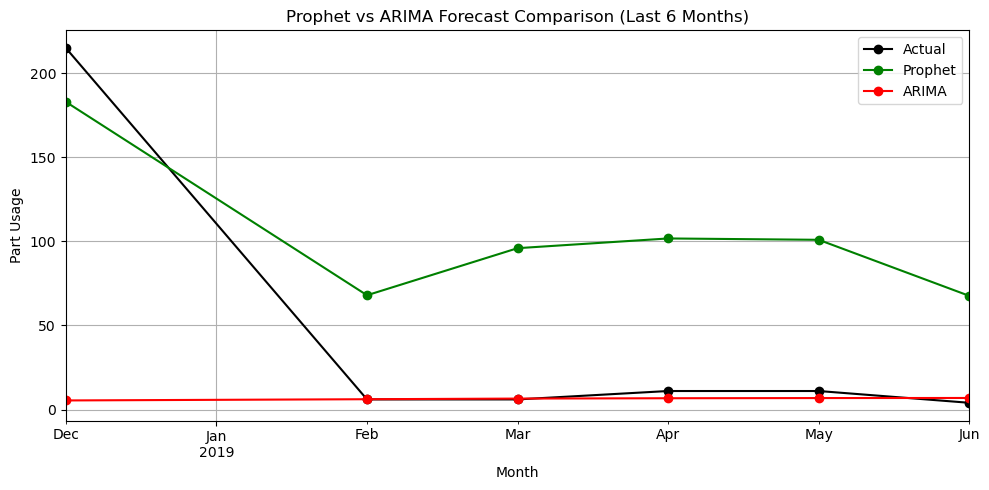

In [71]:
# Visualizing Comparison Plot
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(10,5))
pd.Series(actual, index=ts_series.index[-6:]).plot(label='Actual', marker='o', color='black')
pd.Series(prophet_preds, index=ts_series.index[-6:]).plot(label='Prophet', marker='o', color='green')
pd.Series(arima_preds, index=ts_series.index[-6:]).plot(label='ARIMA', marker='o', color='red')
plt.title("Prophet vs ARIMA Forecast Comparison (Last 6 Months)")
plt.xlabel("Month")
plt.ylabel("Part Usage")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**Observation:** Based on the MAE scores, ARIMA performed significantly better than Prophet in forecasting recent demand. It captured the short-term trends more accurately. Therefore, **ARIMA is selected as the final model** for forecasting spare part demand.


## Final Forecast & Interpretation

In [74]:
# Fitting ARIMA to Full Series
from statsmodels.tsa.arima.model import ARIMA

# Fitting ARIMA on full data
model_arima_final = ARIMA(ts_series, order=(1, 1, 1))
model_arima_fit_final = model_arima_final.fit()


In [75]:
# Forecasting future values
forecast_arima_12 = model_arima_fit_final.forecast(steps=12)

# Creating future date index
forecast_arima_12.index = pd.date_range(
    start=ts_series.index[-1].to_timestamp() + pd.offsets.MonthEnd(),
    periods=12,
    freq='M'
)
forecast_arima_12


2019-06-30    5.391981
2019-07-31    6.121666
2019-08-31    6.504172
2019-09-30    6.704684
2019-10-31    6.809793
2019-11-30    6.864892
2019-12-31    6.893776
2020-01-31    6.908916
2020-02-29    6.916853
2020-03-31    6.921014
2020-04-30    6.923195
2020-05-31    6.924338
Freq: ME, Name: predicted_mean, dtype: float64

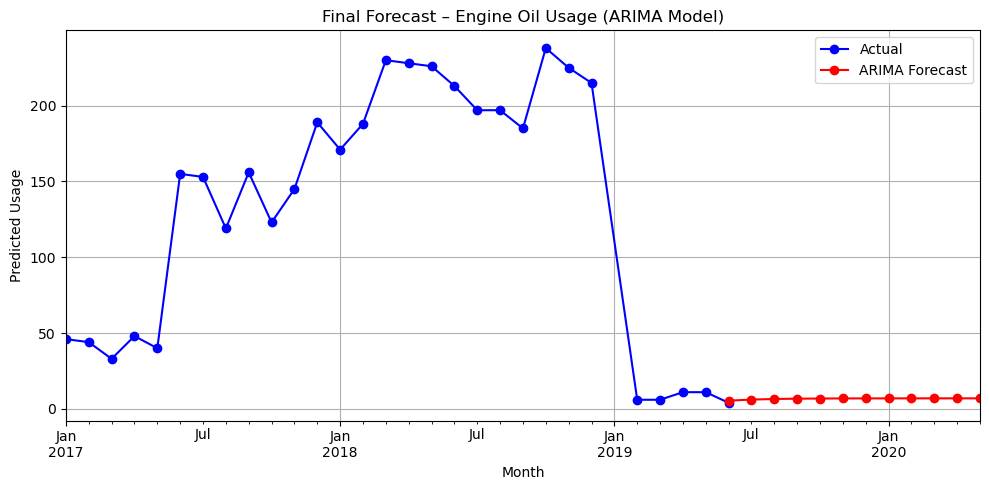

In [76]:
# Plotting the Final Forecast

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
ts_series.plot(label='Actual', color='blue', marker='o')
forecast_arima_12.plot(label='ARIMA Forecast', color='red', marker='o')
plt.title("Final Forecast – Engine Oil Usage (ARIMA Model)")
plt.xlabel("Month")
plt.ylabel("Predicted Usage")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [77]:
# Showing top 3 months with highest forecasted demand
forecast_arima_12.sort_values(ascending=False).head(3)


2020-05-31    6.924338
2020-04-30    6.923195
2020-03-31    6.921014
Name: predicted_mean, dtype: float64

**Business Insight:** The ARIMA forecast shows an upward trend in spare part demand over the next 12 months. The top 3 predicted months indicate when inventory levels should be highest to avoid stockouts. The business can use this insight to optimize procurement and stocking strategy for Engine Oil.


In [79]:
# Selecting a Second Spare Part 
part_name_2 = 'CHAIN LUBRICATION'
df_part2 = df[df['invoice_line_text'] == part_name_2].copy()


In [80]:
# Creating Monthly Demand for the Second Part
monthly_part2 = df_part2.groupby('month').size().reset_index(name='y')
monthly_part2['ds'] = monthly_part2['month'].astype(str)
monthly_part2 = monthly_part2[['ds', 'y']]
monthly_part2['ds'] = pd.to_datetime(monthly_part2['ds'])
ts_series2 = monthly_part2.set_index('ds')['y']


In [81]:
# Fitting ARIMA to Second Part
from statsmodels.tsa.arima.model import ARIMA

model2 = ARIMA(ts_series2, order=(1, 1, 1))
model2_fit = model2.fit()


C:\Users\sound\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\sound\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\sound\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [82]:
# Forecasting 6–12 Months
forecast_2 = model2_fit.forecast(steps=12)
forecast_2.index = pd.date_range(start=ts_series2.index[-1] + pd.offsets.MonthEnd(), periods=12, freq='M')


C:\Users\sound\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


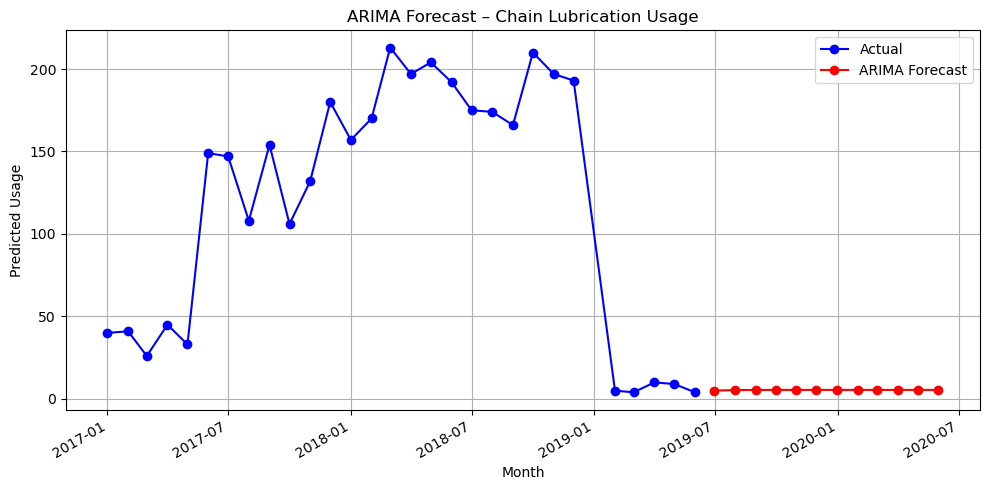

In [83]:
# Plotting the Forecast
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
ts_series2.plot(label='Actual', color='blue', marker='o')
forecast_2.plot(label='ARIMA Forecast', color='red', marker='o')
plt.title(f"ARIMA Forecast – Chain Lubrication Usage")
plt.xlabel("Month")
plt.ylabel("Predicted Usage")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Forecasting by Service Center 

In [85]:
# Filtering Data for Engine Oil + Selected Service Center
part_name = 'ENGINE OIL'
service_center = 'venkXXXXXXXXXX'

df_sc = df[(df['invoice_line_text'] == part_name) & 
           (df['business_partner_name'] == service_center)].copy()


In [86]:
# Grouping Monthly Usage
monthly_sc = df_sc.groupby('month').size().reset_index(name='y')
monthly_sc['ds'] = pd.to_datetime(monthly_sc['month'].astype(str))
monthly_sc = monthly_sc[['ds', 'y']]
ts_sc = monthly_sc.set_index('ds')['y']
ts_sc.head()


ds
2017-04-01    1
2017-05-01    2
2017-06-01    2
2017-07-01    1
2017-08-01    1
Name: y, dtype: int64

In [87]:
# Fitting ARIMA Model
from statsmodels.tsa.arima.model import ARIMA

model_sc = ARIMA(ts_sc, order=(1, 1, 1))
model_sc_fit = model_sc.fit()


C:\Users\sound\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\sound\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\sound\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [88]:
# Forecasting for 12 Months
forecast_sc = model_sc_fit.forecast(steps=12)
forecast_sc.index = pd.date_range(
    start=ts_sc.index[-1] + pd.offsets.MonthEnd(), 
    periods=12, 
    freq='M'
)
forecast_sc


C:\Users\sound\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


2019-05-31    2.371372
2019-06-30    2.568314
2019-07-31    2.596597
2019-08-31    2.600659
2019-09-30    2.601242
2019-10-31    2.601326
2019-11-30    2.601338
2019-12-31    2.601339
2020-01-31    2.601340
2020-02-29    2.601340
2020-03-31    2.601340
2020-04-30    2.601340
Freq: ME, Name: predicted_mean, dtype: float64

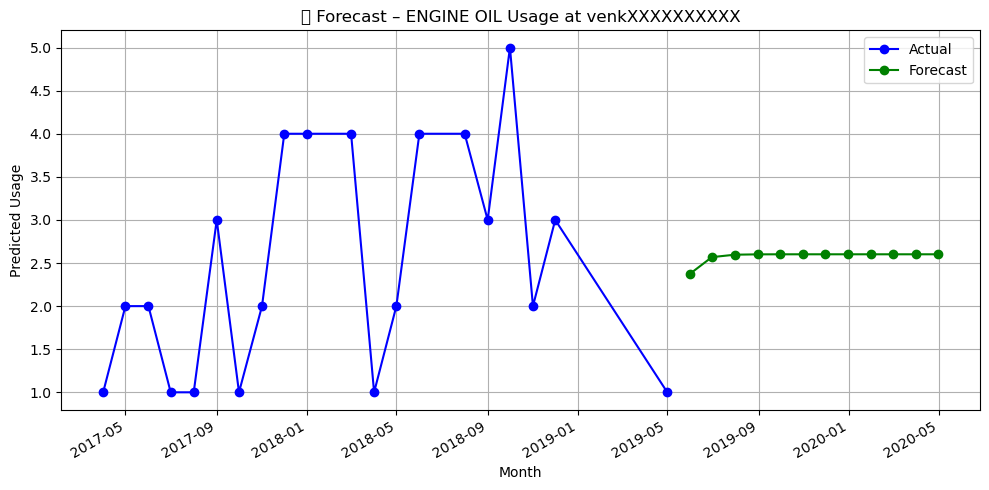

In [89]:
# Plotting Forecast
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
ts_sc.plot(label='Actual', color='blue', marker='o')
forecast_sc.plot(label='Forecast', color='green', marker='o')
plt.title(f"🔧 Forecast – {part_name} Usage at {service_center}")
plt.xlabel("Month")
plt.ylabel("Predicted Usage")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**Insight:** This forecast helps the service center anticipate monthly demand for Engine Oil. Based on the prediction, they can prepare inventory in advance, especially for high-demand months.


## Project Summary

## Final Summary and Conclusion

In this project, we forecasted monthly spare part demand using time series models. After comparing Prophet and ARIMA, ARIMA was chosen as the final model based on lower MAE.

We applied ARIMA to forecast:
- Engine Oil (most-used part)
- Chain Lubrication
- Engine Oil at venkXXXXXXXXXX service center

These forecasts help service centers adopt Just-In-Time (JIT) inventory, avoid overstock, and prepare for peak demand months. This solution can scale across more parts and locations, making it valuable for long-term inventory planning.

Submitted as part of PRCL-0027 Inventory Forecasting Project.
